# Waveguide physics in FDTD - 2

### In the previous lecture, we looked at how to excite a waveguide mode by placing the source directly inside the waveguide. In this lecture, we look at how can we couple to waveguide modes when the source is not embedded inside the waveguide.

For our first example in this lecture, let us examine coupling into a waveguide mode when the illumination. The incident field is a localized continuous-wave source embedded inside the waveguide.

In [1]:
import meep as mp #imports Meep from your package
import numpy as np #Numerical python package for math operations on matrices and etc
import matplotlib.pyplot as plt #plotting package
import math
import cmath
from IPython.display import Video

Using MPI version 4.1, 1 processes


In [2]:
resolution = 20   # pixels/um

w = 1.2           # width of waveguide

sy = 7      # size of cell in y direction (perpendicular to wvg.)
pad = 2           # padding between last hole and PML edge
dpml = 1          # PML thickness

sx = 2*(pad+dpml+3)+1.5-1  # size of cell in x direction
cell = mp.Vector3(sx,sy,0)
pml_layers = [mp.PML(1.0)]

We will create two geometrical objects: 
1) Simple waveguide with $\epsilon=13$
2) Same waveguide but now with holes. 

In [3]:
eps = 13        # dielectric constant of waveguide
geometry_without_holes = [mp.Block(size=mp.Vector3(mp.inf,w,mp.inf), material=mp.Medium(epsilon=eps))]

## geometry with holes

r = 0.36          # radius of holes
d = 1.          # defect spacing (ordinary spacing = 1)
N = 3        # number of holes on either side of defect

geometry_with_holes = geometry_without_holes.copy()
for i in range(N):
        geometry_with_holes.append(mp.Cylinder(r, center=mp.Vector3(d/2+i)))
        geometry_with_holes.append(mp.Cylinder(r, center=mp.Vector3(-(d/2+i))))

Next, we define a source. We choose a line source embedded outside the waveguide.

In [4]:
fcen = 0.25   # pulse center frequency
df = 0.2       # pulse frequency width

src = [mp.Source(mp.GaussianSource(fcen, fwidth=df,is_integrated=True),
                     component=mp.Hz,
                     center=mp.Vector3(y=0.5*sy-dpml),
                     size=mp.Vector3(sx,0))]

In [5]:
sim = mp.Simulation(cell_size=cell,
                        #geometry=geometry_without_holes,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

freg = mp.FluxRegion(center=mp.Vector3(y=-0.5*sy+dpml+0.3),
                         size=mp.Vector3(x=sx - 2*dpml - 0.6))
nfreq = 500 # number of frequencies at which to compute flux

    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, freg)

<Axes: xlabel='X', ylabel='Y'>

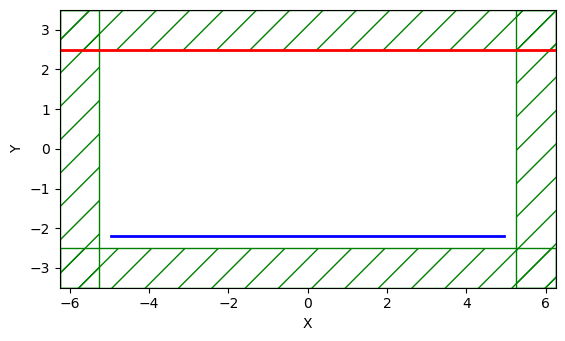

In [6]:
sim.plot2D()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000238385 s
Working in 2D dimensions.
Computational cell is 12.5 x 7 x 0 with resolution 20
time for set_epsilon = 0.0696062 s
-----------


field decay(t = 50.025000000000006): 0.24941775892092108 / 0.24941775892092108 = 1.0
field decay(t = 100.05000000000001): 2.912618807620736e-09 / 0.24941775892092108 = 1.1677672112129729e-08
Normalizing field data...
run 0 finished at t = 100.05000000000001 (4002 timesteps)
Generating MP4...


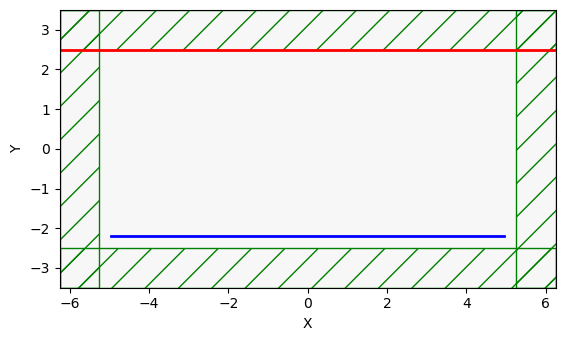

In [7]:
animate = mp.Animate2D(fields=mp.Hz, realtime=False, normalize=True) #Meep object for animating fields

sim.run(mp.at_every(5,animate),
        until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(y=-0.5*sy+dpml+0.5), 1e-3),

)
filename = "waveguide_coupling.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Let us record the flux measured at the detector. This shall be the normalization for the future runs.

Text(0, 0.5, 'Transmitted flux')

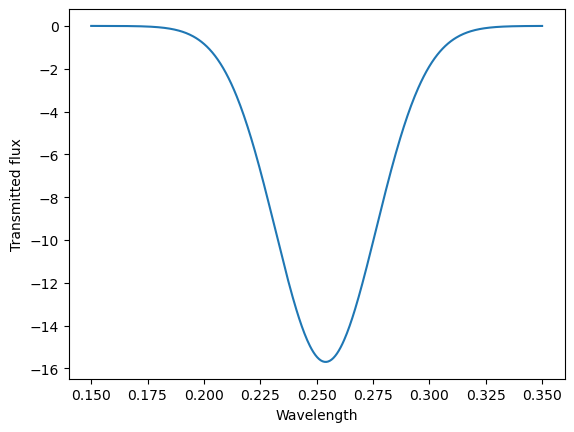

In [8]:
wvl = 1/np.array(mp.get_flux_freqs(trans))
t0 = mp.get_fluxes(trans)
plt.plot(1/wvl,t0)
plt.xlabel('Wavelength')
plt.ylabel('Transmitted flux')

In [9]:
sim.reset_meep()

Now, let us use the waveguide with holes. Everything else in the simulation remains as before.

     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     cylinder, center = (0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant eps

<Axes: xlabel='X', ylabel='Y'>

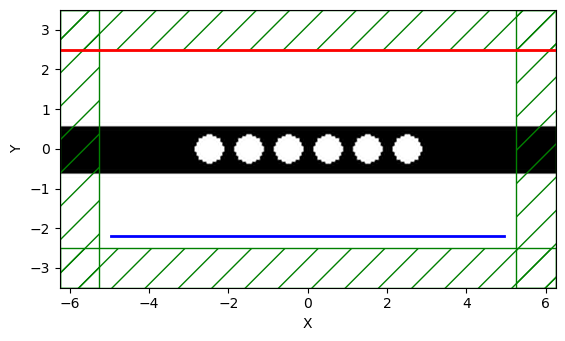

In [10]:
sim = mp.Simulation(cell_size=cell,
                        geometry=geometry_with_holes,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)


    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, freg)
sim.plot2D()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000507451 s
Working in 2D dimensions.
Computational cell is 12.5 x 7 x 0 with resolution 20
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     cylinder, center = (0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          die

          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.159774 s
-----------
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     cylinder, center = (0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, ce

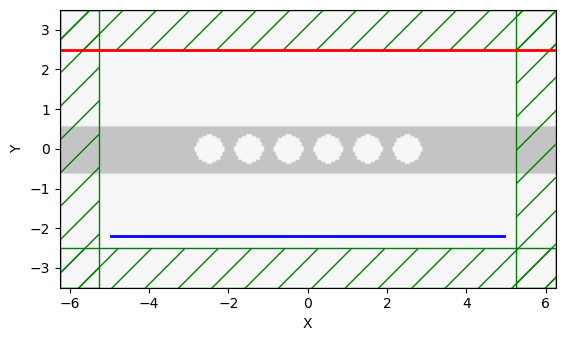

In [11]:
animate = mp.Animate2D(fields=mp.Hz, realtime=False, normalize=True) #Meep object for animating fields

sim.run(mp.at_every(2,animate),
                until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(y=-0.5*sy+dpml+0.4), 1e-4))

filename = "waveguide_coupling.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Text(0, 0.5, 'Transmittance')

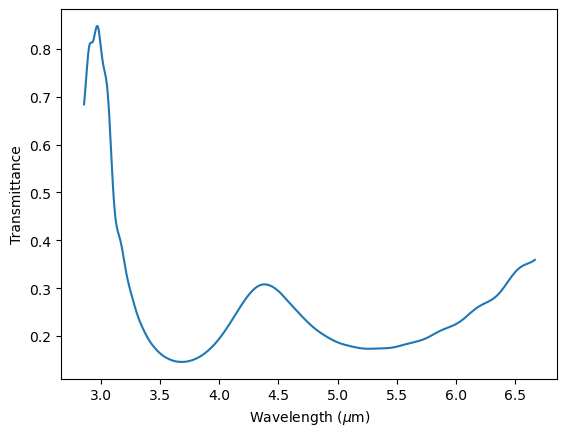

In [12]:
t_holes = mp.get_fluxes(trans)
plt.plot(wvl,t_holes/np.array(t0))
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Transmittance')

To understand why we see a peak in the transmittance at $\lambda\approx4.4\mu\text{m}$, we excite a source inside the hole waveguide.

In [14]:
sim.reset_meep()

First, let us evaluate the energy inside the waveguide without the holes.

     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)


<Axes: xlabel='X', ylabel='Y'>

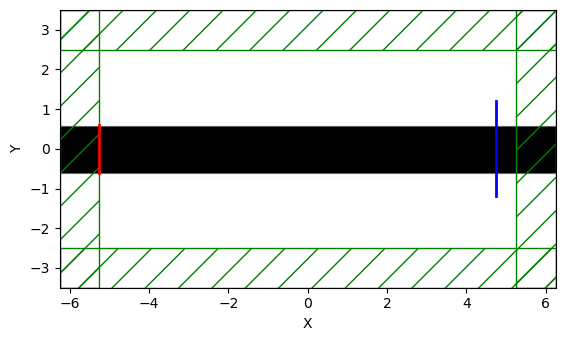

In [131]:
src = [mp.Source(mp.GaussianSource(fcen, fwidth=df),
                     component=mp.Hz,
                     center=mp.Vector3(-0.5*sx+dpml),
                     size=mp.Vector3(0,w))]



sim = mp.Simulation(cell_size=cell,
                        geometry=geometry_without_holes,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)


freg = mp.FluxRegion(center=mp.Vector3(0.5*sx-dpml-0.5),
                         size=mp.Vector3(0,2*w))

    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, freg)
sim.plot2D()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000618123 s
Working in 2D dimensions.
Computational cell is 12.5 x 7 x 0 with resolution 20
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)


time for set_epsilon = 0.0858549 s
-----------
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
field decay(t = 50.025000000000006): 0.002082889666633456 / 0.002082889666633456 = 1.0
field decay(t = 100.05000000000001): 6.2329667186984015 / 6.2329667186984015 = 1.0
field decay(t = 150.07500000000002): 1.1030343468628506e-06 / 6.2329667186984015 = 1.7696779024245964e-07
Normalizing field data...
run 0 finished at t = 150.07500000000002 (6003 timesteps)
Generating MP4...


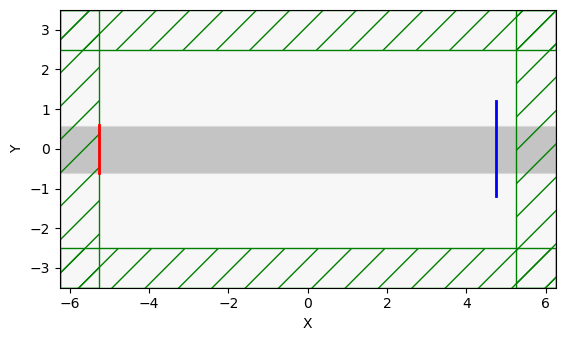

In [132]:
animate = mp.Animate2D(fields=mp.Hz, realtime=False, normalize=True) #Meep object for animating fields

sim.run(mp.at_every(5,animate),
                until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(0.5*sx-dpml-0.5), 1e-3))

filename = "waveguide_coupling.mp4"
animate.to_mp4(2, filename)
Video(filename) #generates the video and saves it under the given filename

In [47]:
t0_inside = mp.get_fluxes(trans)

In [48]:
sim.reset_meep()

     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     cylinder, center = (0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder

, center = (-1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


<Axes: xlabel='X', ylabel='Y'>

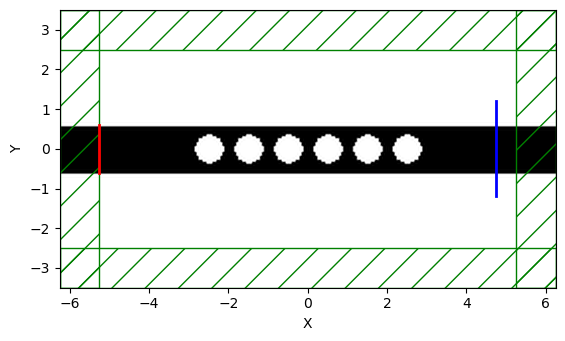

In [49]:
sim = mp.Simulation(cell_size=cell,
                        geometry=geometry_with_holes,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, freg)
sim.plot2D()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000363103 s
Working in 2D dimensions.
Computational cell is 12.5 x 7 x 0 with resolution 20
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     cylinder, center = (0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          die

          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.14639 s
-----------
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     cylinder, center = (0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-1.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (2.5,0,0)
          radius 0.36, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, cen

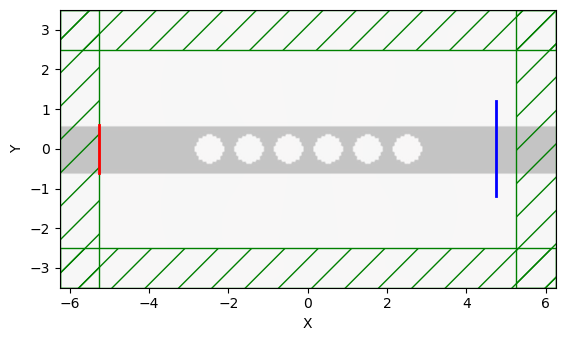

In [50]:
animate = mp.Animate2D(fields=mp.Hz, realtime=False, normalize=True) #Meep object for animating fields

sim.run(mp.at_every(20,animate),
                until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(0.5*sx-dpml-0.5), 1e-3))

filename = "waveguide_coupling.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Text(0, 0.5, 'Transmittance')

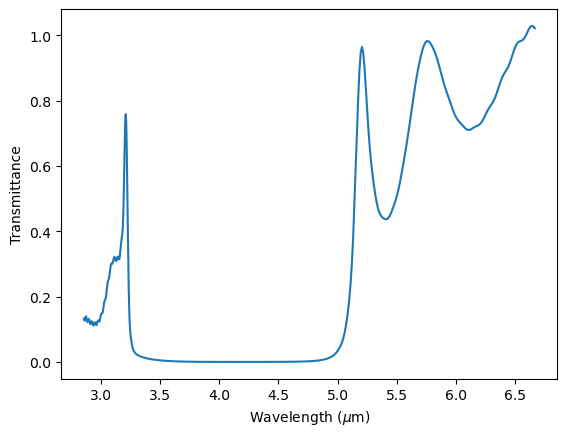

In [53]:
t_inside_with_holes = mp.get_fluxes(trans)
plt.plot(wvl,t_inside_with_holes/np.array(t0_inside))
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Transmittance')

___

## Another way to couple energy into the waveguide is through a simple grating.

In [21]:
sim.reset_meep()

In [22]:
eps = 13        # dielectric constant of waveguide
geometry_without_holes = [mp.Block(size=mp.Vector3(mp.inf,w,mp.inf), material=mp.Medium(epsilon=eps))]

## geometry with holes

r = 0.36          # radius of holes
d = 1.          # defect spacing (ordinary spacing = 1)
N = 5        # number of holes on either side of defect

geometry_with_holes = geometry_without_holes.copy()
r = [0,d,d]
gratx,graty=1.12/2,0.2
for i in range(N):
        j=i*1.12
        geometry_with_holes.append(mp.Block(size=mp.Vector3(gratx,graty), center=mp.Vector3(j,w/2 + graty/2 ) ,material=mp.Medium(epsilon=eps)))
        geometry_with_holes.append(mp.Block(size=mp.Vector3(gratx,graty), center=mp.Vector3(-(j),w/2 + graty/2 ),material=mp.Medium(epsilon=eps)))

     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (0,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-0,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (1.12,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-1.12,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (2.24,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-2.2

<Axes: xlabel='X', ylabel='Y'>

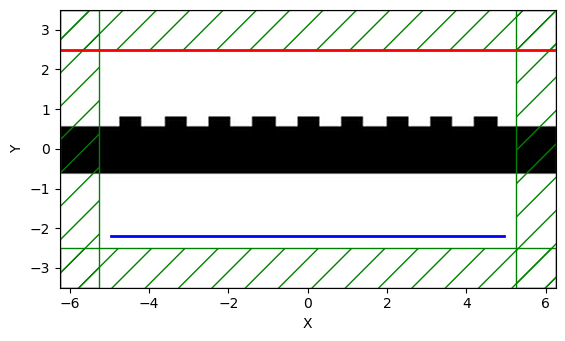

In [23]:

src = [mp.Source(mp.GaussianSource(fcen, fwidth=df,is_integrated=True),
                     component=mp.Hz,
                     center=mp.Vector3(y=0.5*sy-dpml),
                     size=mp.Vector3(sx,0))]

sim = mp.Simulation(cell_size=cell,
                        geometry=geometry_with_holes,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

    # transmitted flux
freg = mp.FluxRegion(center=mp.Vector3(y=-0.5*sy+dpml+0.3),
                         size=mp.Vector3(x=sx - 2*dpml - 0.6))

    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, freg)

sim.plot2D()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000530412 s
Working in 2D dimensions.
Computational cell is 12.5 x 7 x 0 with resolution 20
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (0,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-0,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (1.12,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-1.12,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (2.2

     ...(+ 1 objects not shown)...
time for set_epsilon = 0.118006 s
-----------
     block, center = (0,0,0)
          size (1e+20,1.2,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (0,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-0,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (1.12,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (-1.12,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13,13,13)
     block, center = (2.24,0.7,0)
          size (0.56,0.2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     

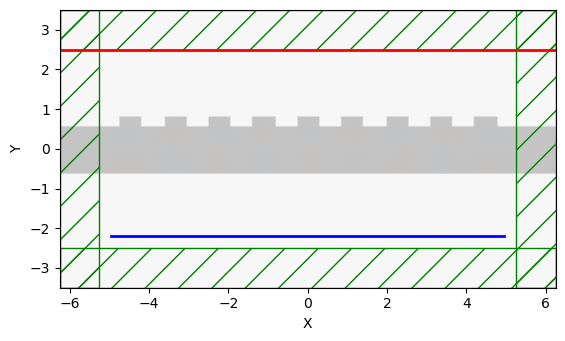

In [24]:
animate = mp.Animate2D(fields=mp.Hz, realtime=False, normalize=True) #Meep object for animating fields

sim.run(mp.at_every(2,animate),
                until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(y=-0.5*sy+dpml+0.4), 1e-4))
#                until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(y=0.5*sx-dpml-0.4), 1e-4))

filename = "waveguide_coupling.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Text(0, 0.5, 'Transmittance')

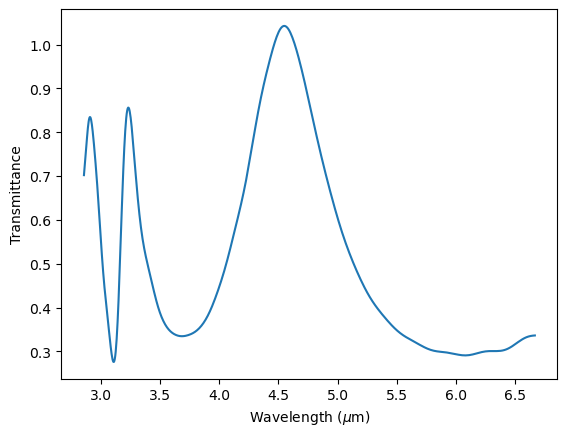

In [27]:
t_grating = mp.get_fluxes(trans)
plt.plot(wvl,t_grating/np.array(t0))

plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Transmittance')

# Assigment for next session 

___

By carefully “breaking” the periodicity in a system, researchers sculpt tiny defects that act as electromagnetic traps. These nanocavities can store light for millions of optical cycles in volumes smaller than a cubic wavelength, dramatically boosting light–matter interaction. Such trapped modes underpin ultra‑low‑power lasers, single‑photon sources, and ultrasensitive sensors—technologies your simulation exercises are just beginning to explore.

Care such a scenario in the case above to have a defect in the center like shown here.

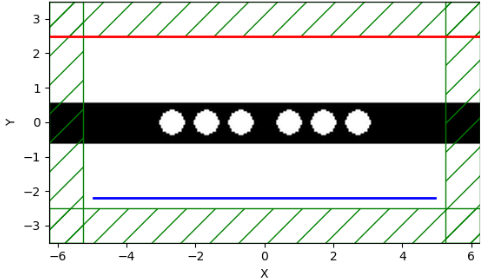

### 1) How does such a defect impact the coupling of light from air? Plot the transmittance with the source in air. Compare your results with the no-defect system simulated above.

### 2) How does such a defect impact the transmittance when the illumination is embedded inside the waveguide? Compare your results with the no-defect system simulated above.